In [4]:
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import pickle

# ==============================
# 1️⃣ LOAD DATASET
# ==============================
df = pd.read_csv("/home/axom/bb/Downloads/Bhawana mam/preprocessed_dataset.csv")
df['clean_text'] = df['clean_text'].astype(str)
df = df[df['clean_text'].notnull()]               # remove NaN if any
df = df[df['clean_text'].str.strip() != ""]   
# ==============================
# 2️⃣ TOKENIZATION
# ==============================
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# ==============================
# 3️⃣ HANDLE LABELS
# ==============================
le = LabelEncoder()
df['label'] = le.fit_transform(df['status']) 

# Save LabelEncoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Remove single-instance classes
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts > 1].index
df = df[df['label'].isin(valid_labels)]

encodings = tokenize_data(df['clean_text'])
labels = torch.tensor(df['label'].values)

# ==============================
# 4️⃣ TRAIN-VAL SPLIT
# ==============================
train_idx, val_idx = train_test_split(
    range(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_encodings = {k: v[train_idx] for k, v in encodings.items()}
val_encodings   = {k: v[val_idx] for k, v in encodings.items()}

train_labels = labels[train_idx]
val_labels   = labels[val_idx]

# ==============================
# 5️⃣ DATASET CLASS
# ==============================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset   = TextDataset(val_encodings, val_labels)

# ==============================
# 6️⃣ ATTENTION LAYER
# ==============================
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attn_weights = self.attn(lstm_output)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights

# ==============================
# 7️⃣ MODEL: CNN + BiLSTM + ATTENTION (SHRUNK)
# ==============================
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embed_dropout = nn.Dropout(0.3)

        # 🔥 Fix 1: Shrunk architecture to prevent memorization
        self.conv = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            bidirectional=True,
            batch_first=True,
            dropout=0.4 # Higher dropout
        )

        self.attention = Attention(128) # 64 * 2 (bidirectional)
        self.dropout = nn.Dropout(0.6)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = self.embed_dropout(x)

        # Apply Attention Mask to zero-out Padding
        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)

        x = x.permute(0, 2, 1)

        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0, 2, 1)

        lstm_out, _ = self.lstm(x)

        attn_out, weights = self.attention(lstm_out)

        out = self.dropout(attn_out)
        logits = self.fc(out)

        return logits, weights.squeeze(2)

# ==============================
# 8️⃣ DEVICE & INIT MODEL
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CNN_BiLSTM_Attention(
    vocab_size=tokenizer.vocab_size,
    embed_dim=128, # 🔥 Shrunk from 300
    num_classes=len(df['label'].unique())
)
model.to(device)

# ==============================
# 9️⃣ LOSS & OPTIMIZER UPDATES
# ==============================
# 🔥 Fix 2: Calculate Class Weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels.cpu().numpy()),
    y=train_labels.cpu().numpy()
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# 🔥 Fix 3: Increased weight decay (L2 Regularization)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

# ==============================
# 🔟 TRAINING LOOP
# ==============================
EPOCHS = 30
patience = 5
best_val_acc = 0
epochs_no_improve = 0

print("\n🚀 Training Started...\n")

for epoch in range(EPOCHS):
    start_time = time.time()

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    preds, true = [], []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        logits, _ = model(input_ids, attention_mask=attention_mask)

        loss = criterion(logits, labels_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true.extend(labels_batch.cpu().numpy())

    train_acc = accuracy_score(true, preds)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)

            logits, _ = model(input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels_batch)

            val_loss += loss.item()
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true.extend(labels_batch.cpu().numpy())

    val_acc = accuracy_score(true, preds)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Model Saved\n")
    else:
        epochs_no_improve += 1
        print(f"No improvement: {epochs_no_improve}\n")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered")
        break

print(f"\n🎉 Training Complete! Best Val Accuracy: {best_val_acc:.4f}")

Using device: cpu

🚀 Training Started...



/home/axom/bb/Downloads/Bhawana mam/.venv/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1 | Train Acc: 0.4127 | Val Acc: 0.5662
💾 Model Saved

Epoch 2 | Train Acc: 0.5513 | Val Acc: 0.6144
💾 Model Saved

Epoch 3 | Train Acc: 0.5900 | Val Acc: 0.6387
💾 Model Saved

Epoch 4 | Train Acc: 0.6207 | Val Acc: 0.6716
💾 Model Saved

Epoch 5 | Train Acc: 0.6551 | Val Acc: 0.6910
💾 Model Saved

Epoch 6 | Train Acc: 0.6715 | Val Acc: 0.7033
💾 Model Saved

Epoch 7 | Train Acc: 0.6853 | Val Acc: 0.7025
No improvement: 1

Epoch 8 | Train Acc: 0.6970 | Val Acc: 0.7057
💾 Model Saved

Epoch 9 | Train Acc: 0.7071 | Val Acc: 0.7206
💾 Model Saved

Epoch 10 | Train Acc: 0.7157 | Val Acc: 0.7182
No improvement: 1

Epoch 11 | Train Acc: 0.7239 | Val Acc: 0.7308
💾 Model Saved

Epoch 12 | Train Acc: 0.7300 | Val Acc: 0.7453
💾 Model Saved

Epoch 13 | Train Acc: 0.7379 | Val Acc: 0.7415
No improvement: 1

Epoch 14 | Train Acc: 0.7420 | Val Acc: 0.7475
💾 Model Saved

Epoch 15 | Train Acc: 0.7471 | Val Acc: 0.7338
No improvement: 1

Epoch 16 | Train Acc: 0.7519 | Val Acc: 0.7305
No improvement: 

                      precision    recall  f1-score   support

             Anxiety       0.78      0.81      0.80       768
             Bipolar       0.84      0.80      0.82       556
          Depression       0.81      0.52      0.64      3081
              Normal       0.91      0.91      0.91      3243
Personality disorder       0.35      0.85      0.50       215
              Stress       0.53      0.64      0.58       517
            Suicidal       0.60      0.79      0.68      2130

            accuracy                           0.75     10510
           macro avg       0.69      0.76      0.70     10510
        weighted avg       0.78      0.75      0.75     10510



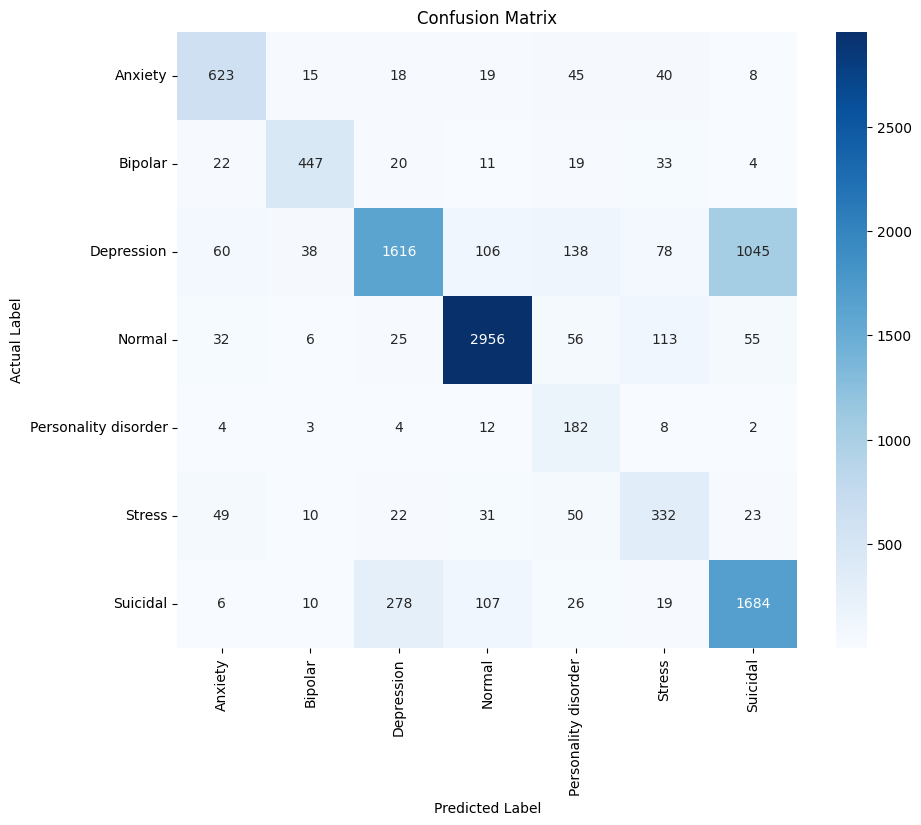

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'true' contains your actual labels and 'preds' contains your model's predictions 
# from your final validation loop

# 1. Print the full Precision, Recall, and F1-Score report
target_names = ["Anxiety", "Bipolar", "Depression", "Normal", "Personality disorder", "Stress", "Suicidal"]
print(classification_report(true, preds, target_names=target_names))

# 2. Plot the Confusion Matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show() # Save this image for your paper!

✅ Saved high-resolution 'accuracy_curve.png' to your folder!


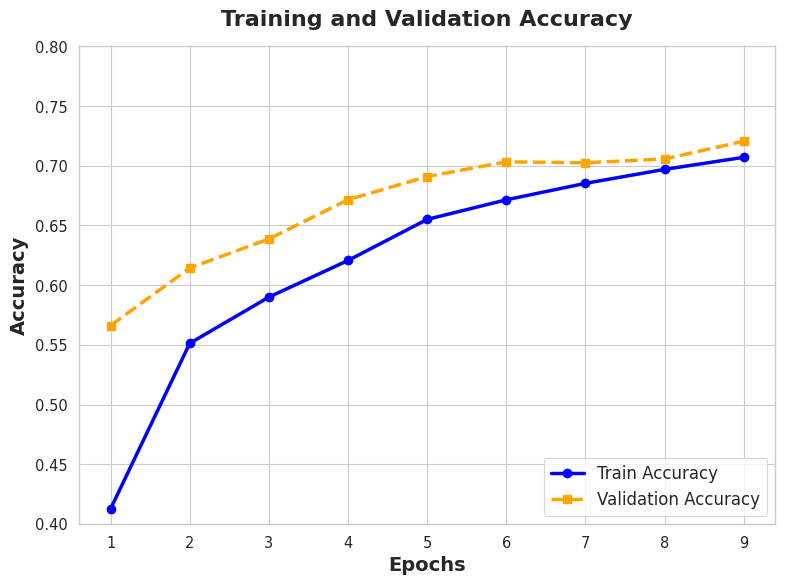

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. YOUR TRAINING DATA
# ==========================================
# Here are your numbers from Epoch 1 to Epoch 9. 
# 🛑 IMPORTANT: If you have the numbers for the hidden epochs (from the "..."), 
# simply add them to the end of these lists!

history_train_acc = [0.4127, 0.5513, 0.5900, 0.6207, 0.6551, 0.6715, 0.6853, 0.6970, 0.7071]
history_val_acc   = [0.5662, 0.6144, 0.6387, 0.6716, 0.6910, 0.7033, 0.7025, 0.7057, 0.7206]

epochs = range(1, len(history_train_acc) + 1)

# ==========================================
# 2. GENERATE THE RESEARCH PAPER PLOT
# ==========================================
# Set style for academic papers
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.figure(figsize=(8, 6))

# Plot the curves
plt.plot(epochs, history_train_acc, label='Train Accuracy', color='blue', linewidth=2.5, marker='o', markersize=6)
plt.plot(epochs, history_val_acc, label='Validation Accuracy', color='orange', linewidth=2.5, linestyle='--', marker='s', markersize=6)

# Formatting
plt.title('Training and Validation Accuracy', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('Epochs', fontweight='bold', fontsize=14)
plt.ylabel('Accuracy', fontweight='bold', fontsize=14)

# Set the Y-axis to clearly show the range from 0.40 to roughly 0.80
plt.ylim(0.40, 0.80) 

plt.legend(loc='lower right', fontsize=12)

# Save and Show
plt.tight_layout()
plt.savefig('accuracy_curve.png', dpi=300, bbox_inches='tight') # Saves a high-res 300 DPI image
print("✅ Saved high-resolution 'accuracy_curve.png' to your folder!")
plt.show()

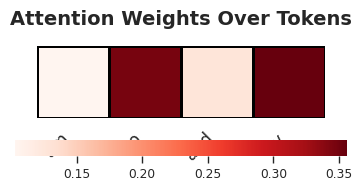

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import re

def plot_attention_heatmap(sentence, model, tokenizer, device):
    model.eval()
    
    # 1. Clean the text
    text = sentence.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text).strip()
    
    # 2. Tokenize
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    
    # 3. Get attention weights
    with torch.no_grad():
        logits, attention_weights = model(input_ids, attention_mask=attention_mask)
        predicted_idx = torch.argmax(logits, dim=1).item()
    
    # 4. Map weights to tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    weights = attention_weights[0].cpu().numpy()
    
    # Adjust for MaxPool1d(2) reduction
    pool_factor = len(tokens) // len(weights)
    mapped_tokens = [tokens[i * pool_factor] for i in range(len(weights))]
    
    # Filter out special tokens [CLS], [SEP] for a cleaner chart
    clean_tokens, clean_weights = [], []
    for token, weight in zip(mapped_tokens, weights):
        if token not in ["[CLS]", "[SEP]", "[PAD]"]:
            clean_tokens.append(token)
            clean_weights.append(weight)
            
    # 5. Plot the Heatmap
    plt.figure(figsize=(12, 2))
    sns.set_theme(style="white", context="paper")
    
    # Reshape weights for a 1D heatmap
    weights_matrix = [clean_weights]
    
    ax = sns.heatmap(
        weights_matrix, 
        xticklabels=clean_tokens, 
        yticklabels=False, # Hide Y axis
        cmap="Reds", # Red highlights look great for attention
        cbar_kws={"orientation": "horizontal", "pad": 0.2},
        square=True,
        linewidths=1,
        linecolor='black'
    )
    
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.title("Attention Weights Over Tokens", fontsize=14, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# === Test it on a sample sentence! ===
sample_text = "I am feeling so exhausted and overwhelmed by everything."
plot_attention_heatmap(sample_text, model, tokenizer, device)